<Figure size 600x400 with 0 Axes>

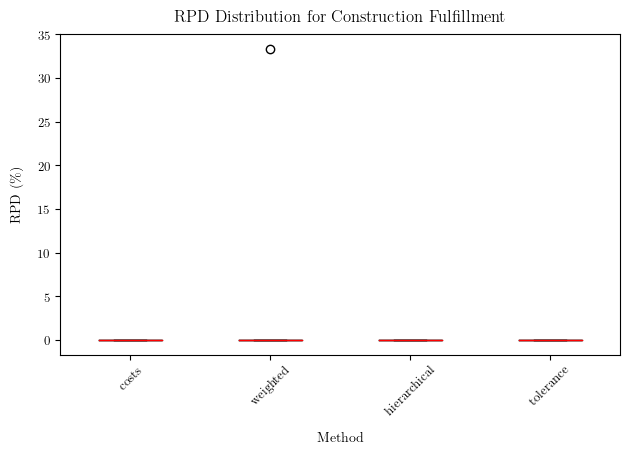

<Figure size 600x400 with 0 Axes>

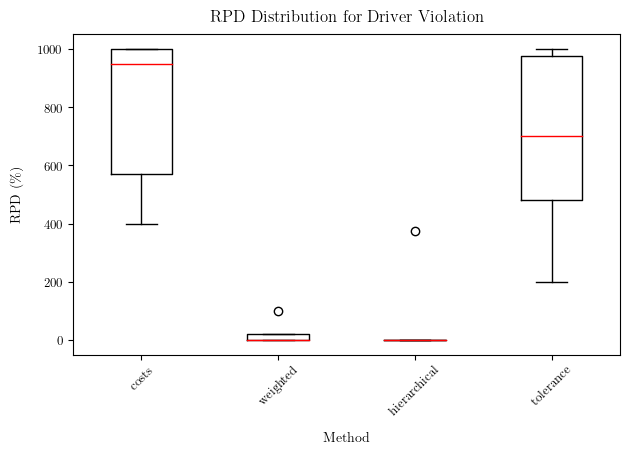

<Figure size 600x400 with 0 Axes>

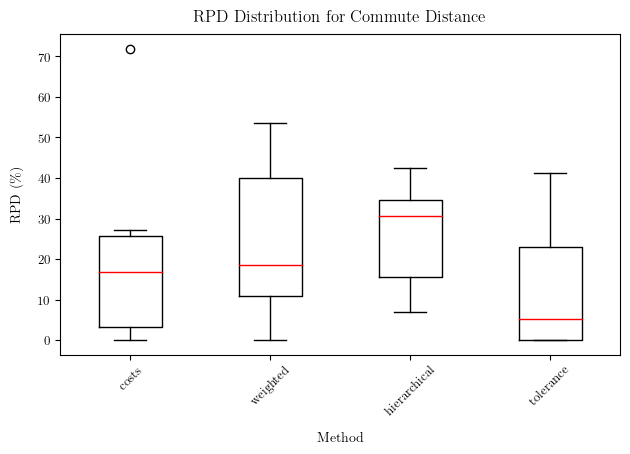

<Figure size 600x400 with 0 Axes>

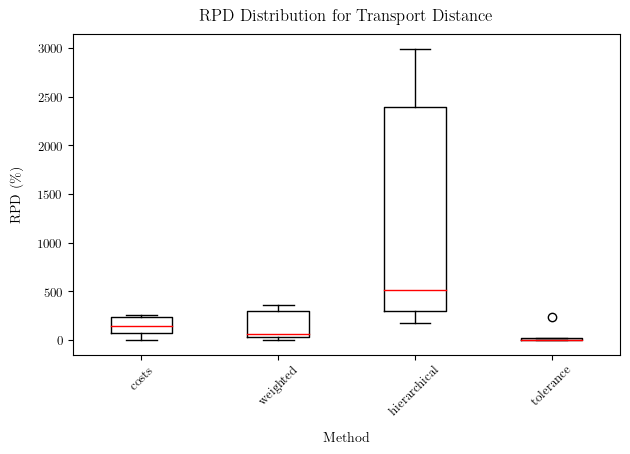

<Figure size 600x400 with 0 Axes>

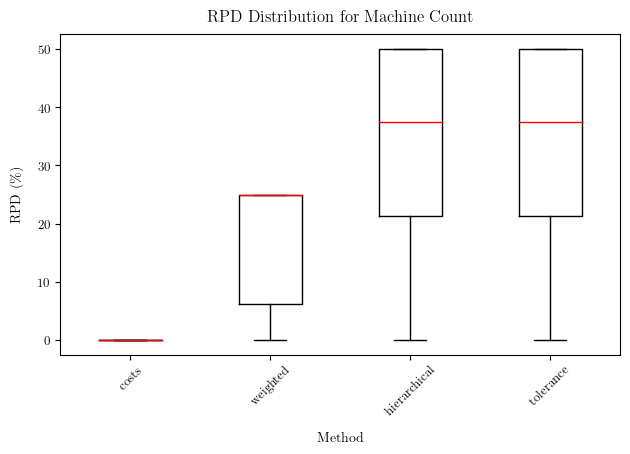

<Figure size 600x400 with 0 Axes>

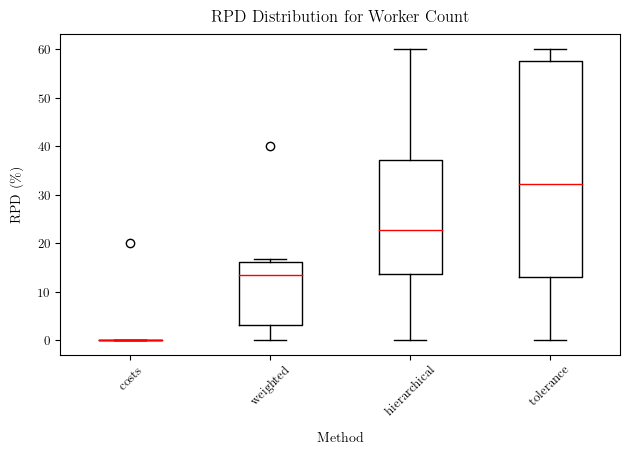

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Globale Einstellungen für LaTeX-Stil und Schriftarten
rcParams.update({
    "text.usetex": True,  # LaTeX-Schriftart verwenden
    "font.family": "serif",  # Serifen-Schrift (wie in wissenschaftlichen Dokumenten)
    "font.size": 10,  # Grundschriftgröße
    "axes.titlesize": 12,  # Titelgröße
    "axes.labelsize": 10,  # Achsenbeschriftung
    "xtick.labelsize": 9,  # Größe der x-Ticks
    "ytick.labelsize": 9,  # Größe der y-Ticks
    "legend.fontsize": 9,  # Legenden-Schriftgröße
    "figure.titlesize": 12  # Figur-Titelgröße
})

# CSV-Daten einlesen
df = pd.read_csv("filtered_results.csv")

# Zielfunktionen definieren
objectives = [
    "Construction Fulfillment",
    "Driver Violation",
    "Commute Distance",
    "Transport Distance",
    "Machine Count",
    "Worker Count"
]

# Bereinigung: Entfernen von "*" und Konvertieren in numerische Werte
for objective in objectives:
    df[objective] = df[objective].astype(str).str.replace("*", "", regex=False)
    df[objective] = pd.to_numeric(df[objective], errors='coerce')

# Berechnung des RPD für jede Zielfunktion
method_order = ["costs", "weighted", "hierarchical", "tolerance"]
df["Method"] = pd.Categorical(df["Method"], categories=method_order, ordered=True)
rpd_columns = []  # Zum Speichern der berechneten RPD-Spalten

for objective in objectives:
    if objective == "Construction Fulfillment":  # Maximierungsproblem
        df["Best Value"] = df.groupby("Instance")[objective].transform('max')
        df[f"{objective} RPD"] = ((df["Best Value"] - df[objective]) / df["Best Value"]) * 100
    else:  # Minimierungsprobleme
        df["Best Value"] = df.groupby("Instance")[objective].transform('min')
        df[f"{objective} RPD"] = ((df[objective] - df["Best Value"]) / df["Best Value"]) * 100
    rpd_columns.append(f"{objective} RPD")

# Boxplots basierend auf RPD erstellen
for objective in objectives:
    plt.figure(figsize=(6, 4))  # Kleinere Größe für wissenschaftliche Darstellung
    df.boxplot(column=f"{objective} RPD", by="Method", grid=False, showfliers=True, color=dict(boxes="black", whiskers="black", medians="red"))
    plt.title(f'RPD Distribution for {objective}', fontsize=12, pad=10)
    plt.suptitle("")  # Entfernt den Standardtitel von Pandas
    plt.xlabel('Method', labelpad=10)
    plt.ylabel('RPD (\%)', labelpad=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"boxplot_{objective.replace(' ', '_').lower()}_with_axis.pdf", format='pdf')  # Speichern als PDF
    plt.show()

<Figure size 600x400 with 0 Axes>

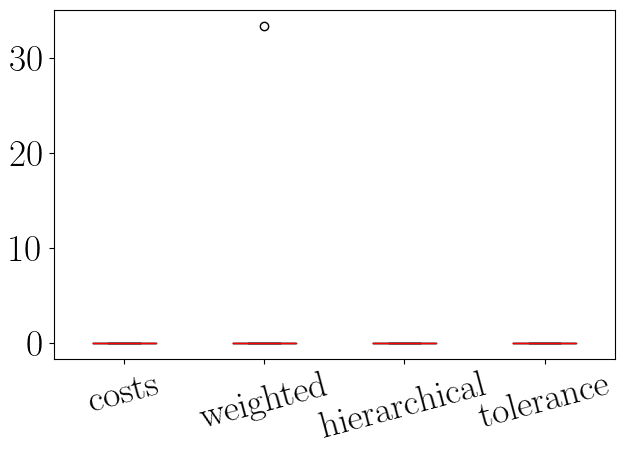

<Figure size 600x400 with 0 Axes>

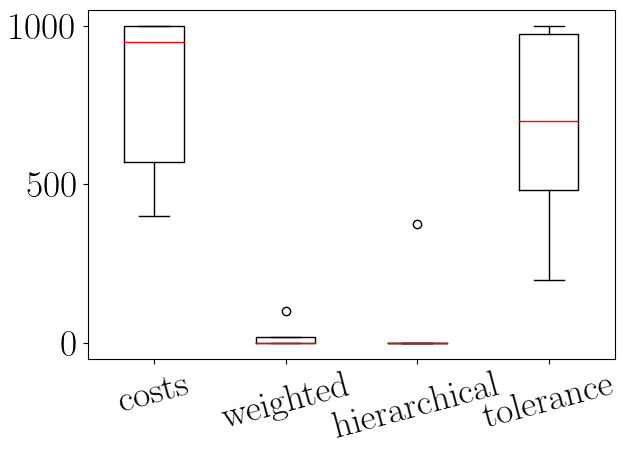

<Figure size 600x400 with 0 Axes>

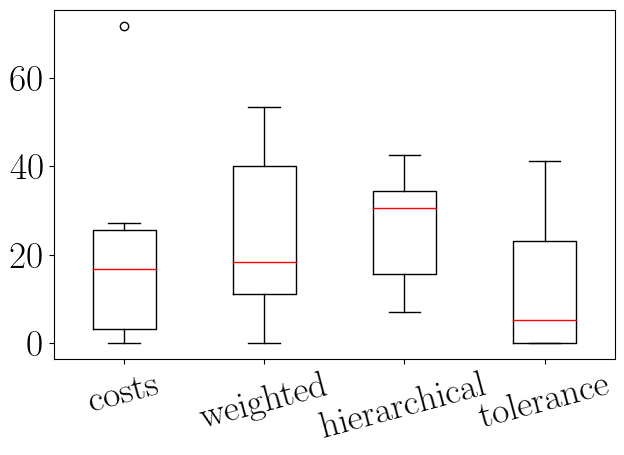

<Figure size 600x400 with 0 Axes>

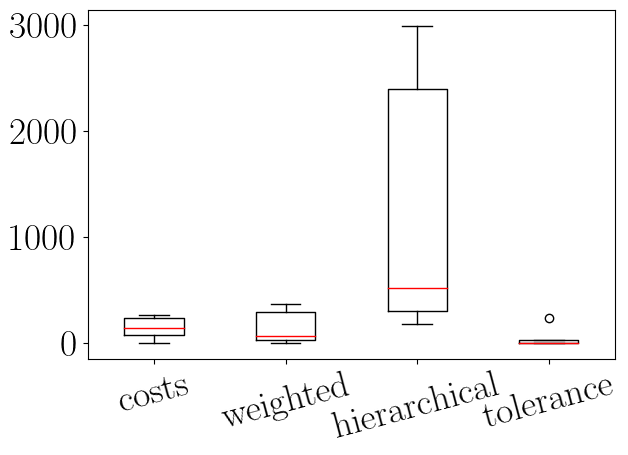

<Figure size 600x400 with 0 Axes>

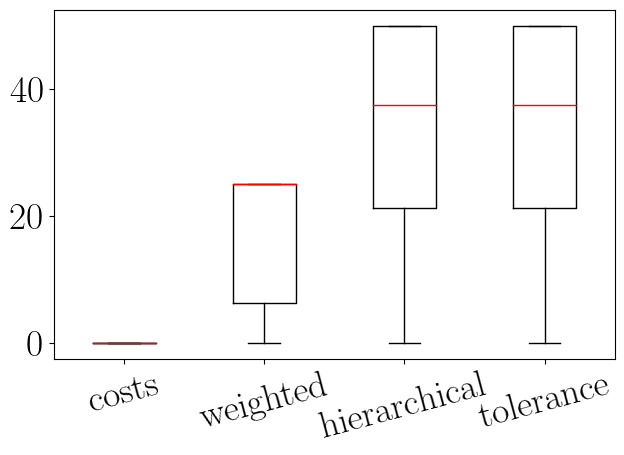

<Figure size 600x400 with 0 Axes>

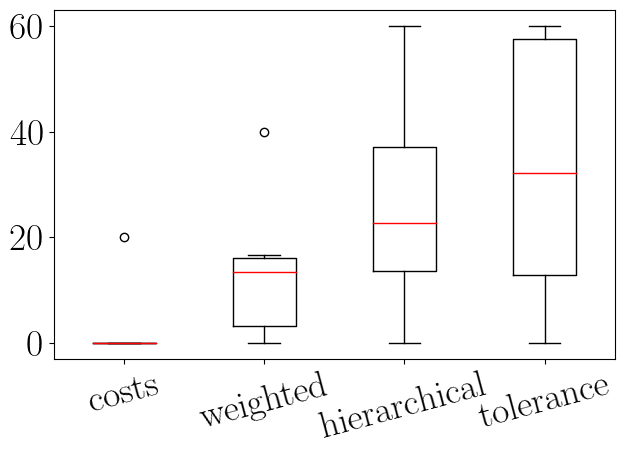

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Globale Einstellungen für LaTeX-Stil und Schriftarten
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 25,
    "axes.labelsize": 120,  # Vergrößert die Achsenbeschriftungen
    "xtick.labelsize": 27,  # Vergrößert die X-Ticks
    "ytick.labelsize": 27   # Vergrößert die Y-Ticks
})

# CSV-Daten einlesen
df = pd.read_csv("filtered_results.csv")

# Zielfunktionen definieren
objectives = [
    "Construction Fulfillment",
    "Driver Violation",
    "Commute Distance",
    "Transport Distance",
    "Machine Count",
    "Worker Count"
]

# Bereinigung: Entfernen von "*" und Konvertieren in numerische Werte
for objective in objectives:
    df[objective] = df[objective].astype(str).str.replace("*", "", regex=False)
    df[objective] = pd.to_numeric(df[objective], errors='coerce')

# Berechnung des RPD für jede Zielfunktion
method_order = ["costs", "weighted", "hierarchical", "tolerance"]
df["Method"] = pd.Categorical(df["Method"], categories=method_order, ordered=True)

for objective in objectives:
    if objective == "Construction Fulfillment":  # Maximierungsproblem
        df["Best Value"] = df.groupby("Instance")[objective].transform('max')
        df[f"{objective} RPD"] = ((df["Best Value"] - df[objective]) / df["Best Value"]) * 100
    else:  # Minimierungsprobleme
        df["Best Value"] = df.groupby("Instance")[objective].transform('min')
        df[f"{objective} RPD"] = ((df[objective] - df["Best Value"]) / df["Best Value"]) * 100

# Speichere jeden Boxplot einzeln als PDF
for objective in objectives:
    plt.figure(figsize=(6, 4))  # Größe für ein einzelnes Diagramm
    ax = df.boxplot(
        column=f"{objective} RPD",
        by="Method",
        grid=False,
        showfliers=True,
        color=dict(boxes="black", whiskers="black", medians="red")
    )
    # Entferne automatisch generierte Überschrift
    plt.suptitle("")  # Entfernt "Boxplot grouped by Method"
    ax.set_title("")  # Entfernt den Titel des Subplots
    ax.set_xlabel("")  # Entfernt X-Achsen-Beschriftung
    ax.set_ylabel("")  # Entfernt Y-Achsen-Beschriftung
    ax.tick_params(axis='x', rotation=15)  # X-Ticks horizontal
    plt.tight_layout()
    

    # Speichere das Diagramm als PDF
    plt.savefig(f"boxplot_{objective.replace(' ', '_').lower()}.pdf", format="pdf")
    plt.show()